<a href="https://colab.research.google.com/github/BrunoNegy/Atividades-Inteligencia-Artificial/blob/main/eleicao_1936_literary_digest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introdução

A eleição presidencial de 1936 nos Estados Unidos, disputada entre Franklin D. Roosevelt e Alf Landon, se tornou um marco histórico para a ciência de dados e para a amostragem estatística. A famosa revista Literary Digest realizou uma pesquisa de grande escala com mais de dois milhões de participantes, prevendo a vitória expressiva de Landon. Porém, o resultado das urnas confirmou a reeleição de Roosevelt por uma margem grande. Esse trabalho tem como objetivo realizar a limpeza dos dados e uma análise exploratória para evidenciar o rumo de amostragem presente na pesquisa da época.

# 1.­ Imports

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, r2_score
from sklearn.linear_model import LinearRegression

# 2.­ Lendo os dados do excel

In [ ]:
df_1936 = pd.read_excel('/content/LitDigestFull.xlsx', sheet_name='1936') #usei o read_excel do pandas pra poder ler o arquivo, e precisei colocar sheet_name pois dentro do arquivo tinha de vários anos, e como estamos focando em 1936 foi necessário

In [ ]:
df_1932 = pd.read_excel('/content/LitDigestFull.xlsx', sheet_name='1932') #aqui fez igual no de cima para os dados da pesquisa de 1932.

# 3.­ Verificando os dados existentes

# 3.1. Head

In [ ]:
df_1936.head() #Mostra as 5 primeiras linhas

,Unnamed: 0,Unnamed: 1,Landon (R),How did they vote in 1932?,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,%.3,Electoral votes.4,Other,%.4,Electoral votes.5,Margin,%.5,Total votes,State,Unnamed: 55
0,State,Electoral Vote,Landon,Rep.,Dem.,Soc.,Others,Did Not Vote,Vote Not Indicated,NaN,...,0.09,-,1397,0.51,-,202838.0,73.56,275244.0,AL,https://en.wikipedia.org/wiki/1936_United_Stat...
1,Alabama,11,3060,1218,1298,3,3,412,126,NaN,...,0.26,-,384,0.31,-,53289.0,42.92,124163.0,AZ,NaN
2,Arizona,3,2337,1431,647,18,0,129,112,NaN,...,0.25,-,169,0.09,-,114726.0,63.94,179423.0,AR,NaN
3,Arkansas,9,2724,1338,953,7,9,274,143,NaN,...,0.43,-,24284,0.92,-,930405.0,35.26,2638882.0,CA,NaN
4,California,22,89516,65360,16200,315,53,3519,4069,NaN,...,0.33,-,841,0.17,-,113754.0,23.28,488684.0,CO,NaN


In [ ]:
df_1932.head()

,Unnamed: 0,Unnamed: 1,HOOVER,How the same Voters voted in 1928,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,ROOSEVELT,...,Thomas (Soc.),%.2,Electoral votes.3,Other,%.3,Electoral votes.4,Margin,%.4,Total votes,Unnamed: 44
0,NaN,Electoral Votes,1932 Total Vote,Rep.,Dem.,Other,Did Not Vote,NaN,NaN,1932 Total Vote,...,2030.0,0.83,–,739.0,0.30,–,173235,70.61,245354.0,https://en.wikipedia.org/wiki/1932_United_Stat...
1,ALABAMA,11,4272,3150,480,1,641,NaN,NaN,20161,...,2618.0,2.21,–,265.0,0.22,–,43160,36.5,118251.0,NaN
2,ARIZONA,3,2574,2022,218,1,333,NaN,NaN,4910,...,1269.0,0.58,–,1224.0,0.55,–,161135,73.06,220562.0,NaN
3,ARKANSAS,9,3712,2997,250,1,464,NaN,NaN,16225,...,63299.0,2.79,–,32608.0,1.44,–,476255,21,2267966.0,NaN
4,CALIFORNIA,22,81834,67017,3847,99,10871,NaN,NaN,148832,...,13591.0,2.97,–,3611.0,0.79,–,61260,13.38,457696.0,NaN


# 3.2. Shape

In [ ]:
df_1936.shape #mostra a forma do gráfico entre linhas e colunas

(51, 56)

In [ ]:
df_1932.shape

(52, 45)

# 3.3. Info

In [ ]:
df_1936.info() #as informações

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 56 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Unnamed: 0                    51 non-null     object 
 1   Unnamed: 1                    51 non-null     object 
 2   Landon  (R)                   51 non-null     object 
 3   How did they vote in 1932?    51 non-null     object 
 4   Unnamed: 4                    51 non-null     object 
 5   Unnamed: 5                    51 non-null     object 
 6   Unnamed: 6                    51 non-null     object 
 7   Unnamed: 7                    51 non-null     object 
 8   Unnamed: 8                    51 non-null     object 
 9   Unnamed: 9                    0 non-null      float64
 10  Roosevelt  (D)                51 non-null     object 
 11  How did they vote in 1932?.1  51 non-null     object 
 12  Unnamed: 12                   51 non-null     object 
 13  Unnamed

In [ ]:
df_1932.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 45 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Unnamed: 0                           51 non-null     object 
 1   Unnamed: 1                           51 non-null     object 
 2   HOOVER                               52 non-null     object 
 3   How the same Voters voted in 1928    52 non-null     object 
 4   Unnamed: 4                           52 non-null     object 
 5   Unnamed: 5                           52 non-null     object 
 6   Unnamed: 6                           52 non-null     object 
 7   Unnamed: 7                           0 non-null      float64
 8   Unnamed: 8                           0 non-null      float64
 9   ROOSEVELT                            52 non-null     object 
 10  How the same Voters voted in 1928.1  52 non-null     object 
 11  Unnamed: 11                       

# 3.4. Describe

In [ ]:
df_1936.describe() #a descrição detalhada, contendo count, mean, std, min, max, etc

,Unnamed: 9,Unnamed: 17,Unnamed: 25,Unnamed: 33,Electoral votes,Roosevelt,%,Landon,%.1,Margin,%.5,Total votes
count,0.0,0.0,0.0,0.0,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,4.900000e+01
mean,NaN,NaN,NaN,NaN,21.673469,1.132766e+06,64.652653,6.809107e+05,32.978980,4.518688e+05,31.673673,1.863179e+06
std,NaN,NaN,NaN,NaN,74.808474,3.940307e+06,12.574029,2.378896e+06,11.829567,1.567596e+06,24.273271,6.490007e+06
min,NaN,NaN,NaN,NaN,3.000000,3.192500e+04,41.520000,1.646000e+03,1.430000,-4.249000e+04,-13.970000,4.384800e+04
25%,NaN,NaN,NaN,NaN,4.000000,1.573180e+05,56.880000,6.455500e+04,27.590000,8.569100e+04,16.400000,2.305120e+05
50%,NaN,NaN,NaN,NaN,9.000000,3.280830e+05,60.800000,1.688230e+05,36.540000,1.581770e+05,25.310000,4.886840e+05
75%,NaN,NaN,NaN,NaN,13.000000,7.344850e+05,69.340000,3.977270e+05,40.180000,3.170610e+05,40.840000,1.142733e+06
max,NaN,NaN,NaN,NaN,531.000000,2.775265e+07,98.570000,1.668186e+07,56.390000,1.107079e+07,97.150000,4.564770e+07


In [ ]:
df_1932.describe()

,Unnamed: 7,Unnamed: 8,Unnamed: 14,Unnamed: 15,Unnamed: 23,Unnamed: 25,Unnamed: 26,Electoral votes,Roosevelt,%,Hoover,%.1,Thomas (Soc.),%.2,Other,%.3,Total votes
count,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.000000,4.900000e+01,49.000000,4.900000e+01,49.000000,49.000000,49.000000,49.000000,49.000000,4.900000e+01
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21.673469,9.314807e+05,62.660000,6.433165e+05,35.076735,36117.755102,1.627347,11611.510204,0.636735,1.622526e+06
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.808474,3.231771e+06,13.945857,2.245564e+06,13.245745,127692.119176,1.227624,40910.494044,0.919201,5.642061e+06
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,2.875600e+04,41.080000,1.978000e+03,1.890000,0.000000,0.000000,0.000000,0.000000,4.143000e+04
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.000000,1.401680e+05,54.470000,7.141700e+04,30.530000,1551.000000,0.540000,265.000000,0.140000,2.205620e+05
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,2.594730e+05,58.660000,1.666310e+05,36.880000,4450.000000,1.360000,2235.000000,0.440000,4.576960e+05
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,7.074100e+05,68.460000,3.947160e+05,43.310000,20480.000000,2.460000,5203.000000,0.750000,1.036687e+06
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,531.000000,2.282128e+07,98.030000,1.576125e+07,57.660000,884885.000000,4.790000,284482.000000,5.830000,3.975190e+07


# 3.5. Verificando nulos

In [ ]:
df_1936.isnull().sum() #aqui fiz a primeira verificação de nulos para entender o que precisaria ser limpo

,0
Unnamed: 0,0
Unnamed: 1,0
Landon (R),0
How did they vote in 1932?,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,0
Unnamed: 8,0
Unnamed: 9,51


In [ ]:
df_1932.isnull().sum()

,0
Unnamed: 0,1
Unnamed: 1,1
HOOVER,0
How the same Voters voted in 1928,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,52
Unnamed: 8,52
ROOSEVELT,0


Identificamos a presença de colunas totalmente nulas, e a presença de linhas dentro de colunas que precisam ser apagadas, por isso separei a divisão delas a seguir

# 4.­ Remoção de colunas desnecessárias

In [ ]:
df_1936 = df_1936.dropna(how='all', axis=1) #essa linha faz com que todas as colunas sem informações sejam apagadas
df_1936 = df_1936.drop(columns=['Unnamed: 55']) #precisei executar essa linha de código para excluir especificamente a unnamed: 55 que não foi apagada antes

In [ ]:
df_1936.isnull().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Landon (R),0
How did they vote in 1932?,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,0
Unnamed: 8,0
Roosevelt (D),0


In [ ]:
df_1932 = df_1932.dropna(how='all', axis=1)
df_1932 = df_1932.drop(columns=['Unnamed: 44'])

In [ ]:
df_1932.isnull().sum()

,0
Unnamed: 0,1
Unnamed: 1,1
HOOVER,0
How the same Voters voted in 1928,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
ROOSEVELT,0
How the same Voters voted in 1928.1,0
Unnamed: 11,0


# 5.­ Remoção de linhas desnecessárias

In [ ]:
df_1936 = df_1936.dropna(how='all', axis=0) #aqui eu usei esse comando para limpar as linhas que não tinham nada

In [ ]:
df_1932 = df_1932.dropna(how='all', axis=0)

In [ ]:
df_1936.isnull().sum()

,0
Unnamed: 0,0
Unnamed: 1,0
Landon (R),0
How did they vote in 1932?,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
Unnamed: 7,0
Unnamed: 8,0
Roosevelt (D),0


In [ ]:
df_1932.isnull().sum()

,0
Unnamed: 0,1
Unnamed: 1,1
HOOVER,0
How the same Voters voted in 1928,0
Unnamed: 4,0
Unnamed: 5,0
Unnamed: 6,0
ROOSEVELT,0
How the same Voters voted in 1928.1,0
Unnamed: 11,0


# 6.­ Remoção de linhas sem nome

algumas linhas ficaram sobrando por conta da formatação, e por conta disso, pesquisei como solucionar

In [ ]:
df_1936 = df_1936.dropna(subset=['State - 1936']) #aqui usei esse comando para o pandas olhas especificamente para a coluna do nome do estado, e caso estiver em branco as linhas, ele apaga, se não ele mantem
df_1936 = df_1936.loc[:, ~df_1936.columns.str.contains('^Unnamed')] #aqui sobrou algumas então usei esse comando para apagar especificamente as colunas que contenham o nome Unnamed

In [ ]:
df_1936.isnull().sum()

,0
Landon (R),0
How did they vote in 1932?,0
Roosevelt (D),0
How did they vote in 1932?.1,0
Lemke (Union),0
How did they vote in 1932?.2,0
MINOR CANDIDATES,0
Grand Total Votes,0
State - 1936,0
Electoral votes,0


In [ ]:
df_1932 = df_1932.dropna(subset=['State - 1932'])
df_1932 = df_1932.loc[:, ~df_1932.columns.str.contains('^Unnamed')]
df_1932 = df_1932.dropna(subset=["Electoral votes.4"])

In [ ]:
df_1932.isnull().sum()

,0
HOOVER,0
How the same Voters voted in 1928,0
ROOSEVELT,0
How the same Voters voted in 1928.1,0
VOTES FOR MINOR CANDIDATES,0
GRAND TOTAL VOTES,0
State - 1932,0
Electoral votes,0
Roosevelt,0
%,0


## 7. Remover linhas Totais de cada um dos dataframe

In [ ]:
df_1932_reg = df_1932[
    df_1932["State - 1932"] != "Total"
].copy() #copia tudo que for diferente da coluna Total para um novo dataframe _reg

df_1936_reg = df_1936[
    df_1936["State - 1936"] != "Total"
].copy()

Criando duas copias dos dataframes sem as colunas Total, já que ela será inutil na regressão

In [ ]:
df_1936_reg["Landon  (R)"] = pd.to_numeric(
    df_1936_reg["Landon  (R)"], errors="coerce"
) #transforma os dados de votos de cada estado de cada candidato em numero, para facilitar calculos futuros.

df_1936_reg["Roosevelt  (D)"] = pd.to_numeric(
    df_1936_reg["Roosevelt  (D)"], errors="coerce"
)

df_1936_reg["Lemke (Union)"] = pd.to_numeric(
    df_1936_reg["Lemke (Union)"], errors="coerce"
)

Transformando os dados em numericos, para calculos futuros.

In [ ]:
df_1936_reg = df_1936_reg.dropna(
    subset=["Landon  (R)", "Roosevelt  (D)", "Lemke (Union)"]
).copy() #dropa todas as linhas que possuam dados nulos.

Dropando mais colunas que podem estar vazias.

#### 7.1 Adicionar porcentagens a pesquisa de 1936

In [ ]:
total_pesquisa_1936 = (
    df_1936_reg["Landon  (R)"] +
    df_1936_reg["Roosevelt  (D)"] +
    df_1936_reg["Lemke (Union)"]
)

df_1936_reg["Roosevelt_pesquisa"] = (
    df_1936_reg["Roosevelt  (D)"] / total_pesquisa_1936 * 100
)
df_1936_reg["Landon_pesquisa"] = (
    df_1936_reg["Landon  (R)"] / total_pesquisa_1936 * 100
)
df_1936_reg["Lemke_pesquisa"] = (
    df_1936_reg["Lemke (Union)"] / total_pesquisa_1936 * 100
) #soma o total de pessoas ouvidas na pesquisa, em seguida calcula a porcentagem de cada candidato.

Para facilitar o trabalho futuramente, criei porcentagens na pesquisa de intenção de voto em cada um dos estados/canditados

## 7.2 Criando uma margem de erro do resultado real de 36, para a pesquisa da Literary Digest

In [ ]:
df_1936_reg["erro_Roosevelt"] = (
    df_1936_reg["Roosevelt_pesquisa"] -
    df_1936_reg["%"]
) #cria uma margem de erro no roosevelt, comparando o resultado da pesquisa dele com o reultado final da eleição dele.

Aqui cria uma coluna margem de erro, subtraindo o valor da pesquisa de intencao de voto, pela quantidade de votos recebidos por Roosevelt, assim vamos ver em cada estado a margem de erro.

In [ ]:
print(df_1936_reg[["State - 1936","Landon_pesquisa","Roosevelt_pesquisa","Lemke_pesquisa"]].head())

  State - 1936  Landon_pesquisa  Roosevelt_pesquisa  Lemke_pesquisa
1      Arizona        23.164269           76.320969        0.514762
2     Arkansas        52.921196           44.723732        2.355072
3   California        26.017192           72.664756        1.318052
4     Colorado        52.123584           44.978397        2.898019
5  Connecticut        60.064776           37.754679        2.180545


Printando 5 primeiras porcentagens para ver se tudo está correto.

#7.4 Fundindo os dataframes

In [ ]:
df_reg = df_1936_reg.merge(
    df_1932_reg,
    left_on="State - 1936",
    right_on="State - 1932",
    how="inner"
) #utilizando o comando merge, fundiu os dois dataframes pelos estados, onde 36 fica a esquerda(x) e 32 a direita(y).

Para melhor trabalho futuro, usou .erge para juntar as tabelas de 1936, pesquisa e 1932(resultado)

In [ ]:
print(df_reg[["State - 1936","State - 1932"]].head())

  State - 1936 State - 1932
0      Arizona      Arizona
1     Arkansas     Arkansas
2   California   California
3     Colorado     Colorado
4  Connecticut  Connecticut


Aqui foi printado para ver se a junção foi correta, como pode ver estão agora na mesma tabela.

# 7.5 Analises mais profundas em 1932

In [ ]:
total_pesquisa_1932 = (df_reg["HOOVER"] +df_reg["ROOSEVELT"])
df_reg["Roosevelt_pesquisa_1932"] = (df_reg["ROOSEVELT"] / total_pesquisa_1932 * 100) #parecido com o que foi feito anteriormente, pegamos a porcentagem de roosevelt em 1932

In [ ]:
df_reg["erro_Roosevelt_1932"] = (df_reg["Roosevelt_pesquisa_1932"] -df_reg["%_y"]) #calculo da margem de erro de 1932, com o valor da pesquisa - o valor oficial

In [ ]:
print(df_reg[["State - 1932","Roosevelt_pesquisa_1932","%_y","erro_Roosevelt_1932" ]].head()) #printando os 5 primerios com o estado, resultado da pesquisa e o oficial e a margem de erro.

  State - 1932 Roosevelt_pesquisa_1932    %_y erro_Roosevelt_1932
0      Arizona                82.51545  67.03            15.48545
1     Arkansas               65.606627  85.96          -20.353373
2   California               81.381351  58.39           22.991351
3     Colorado                64.52273  54.81             9.71273
4  Connecticut               54.483126  47.40            7.083126


In [ ]:
df_reg["Roosevelt_corrigido_1936"] = (df_reg["Roosevelt_pesquisa"] - df_reg["erro_Roosevelt_1932"]) #aqui uma correção de quanto deveria ser o valor de roosevelt em 36 com o valor da pesquisa de 36 - a margem de erro de 32.

In [ ]:
df_reg["erro_corrigido_1936"] = (df_reg["Roosevelt_corrigido_1936"] -df_reg["%_x"]) #corrigindo a margem de erro de 1936 com o valor obtido anteriormente(o que deveria ser) - o valor obtido oficialemnte por roosevelt

In [ ]:
df_reg["erro_original_abs"] = df_reg["erro_Roosevelt"].abs() #aqui transformamos a margem de erro de 1936 original em valor absoluto, ou seja, sem valores negativos. Virando pontos percentuais. -20 ou 20 vira 20 pp.

In [ ]:
df_reg["erro_corrigido_abs"] = df_reg["erro_corrigido_1936"].abs() #mesma coisa com a margem de erro corrigida

In [ ]:
print("Erro médio original:",df_reg["erro_original_abs"].mean())
print("Erro médio corrigido:",df_reg["erro_corrigido_abs"].mean()) # aqui tiramos a media dos dois erros absolutos, resultando em valores bem parecidos.

Erro médio original: 23.28304150341117
Erro médio corrigido: 24.131892892036763


Nesse ponto 7.5 foi basicamente trabalhar e estudar melhor os dados da eleição de 1932 para poder usá-los futuramente na regressão linear, iniciamos calculando as porcentagens da pesquisa de 1932, depois sua margem de erro. Com essa margem de erro, tentamos corrigir os valores de votos para Roosevelt em 36 a margem de erro de 1936, para valores mais aceitaveis. Por ultimo, foi transformado o erro original, aquele calculado em 7.2 e a margem de erro mais aceitavel calculado nesse em numeros absolutos, para melhor calculo e finalizando, foi calculada a media das margens de erros.

## 8.­ Graficos para visualização inicial

# 8.1. Gráfico 1: Porcentagem de Votos (Previsão vs. Realidade)

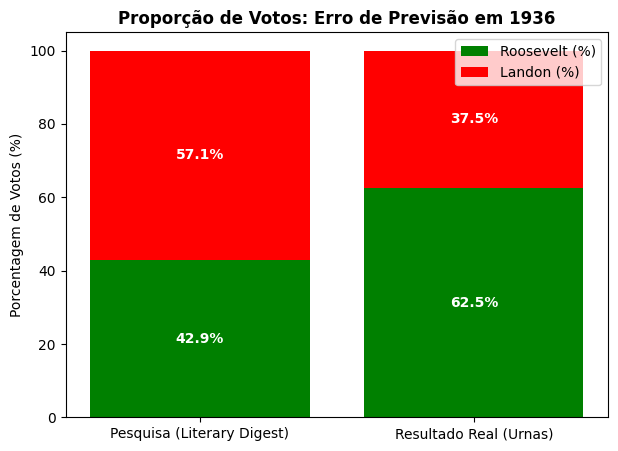

In [ ]:
categorias = ['Pesquisa (Literary Digest)', 'Resultado Real (Urnas)'] #as categorias
roosevelt_pcts = [42.9, 62.5] #Percentual tirado da coluna de resultados presente no excel, fiz uma regra de 3 com os resultados para descobrir as porcentagens
landon_pcts = [57.1, 37.5] #mesma coisa aqui

plt.figure(figsize=(7, 5)) #defini o tamanho do grafico
bar1 = plt.bar(categorias, roosevelt_pcts, label='Roosevelt (%)', color='green')
bar2 = plt.bar(categorias, landon_pcts, bottom=roosevelt_pcts, label='Landon (%)', color='red')

plt.ylabel('Porcentagem de Votos (%)') #criei o titulo ali do lado esquerdo presente no Y
plt.title('Proporção de Votos: Erro de Previsão em 1936', fontweight='bold') #O titulo
plt.legend(loc='upper right') #e movi a legenda pro lado direito pois estava muito poluido do outro lado

#Texto que coloquei na primeira coluna (Pesquisa)
plt.text(0, 42.9 / 2, '42.9%', ha='center', va='center', color='white', fontweight='bold') #Roosevelt (barra de baixo), aqui eu coloquei a primeira coluna, e o alinhamento horizontal e vertical pra ficar certinho, a cor do texto e a fonte negrito
plt.text(0, 42.9 + (57.1 / 2), '57.1%', ha='center', va='center', color='white', fontweight='bold') #Landon (barra de cima: 42.9 + metade de 57.1)

#texto na segunda coluna (Resultado Real)
plt.text(1, 62.5 / 2, '62.5%', ha='center', va='center', color='white', fontweight='bold')#Roosevelt (barra de baixo), mesma coisa aqui
plt.text(1, 62.5 + (37.5 / 2), '37.5%', ha='center', va='center', color='white', fontweight='bold') #Landon (barra de cima: 62.5 + metade de 37.5)

plt.show() #Aqui eu mostrei

Esse gráfico mostra claramente o erro da previsão de 1936, notamos que na barra da esquerda, onde se trata da pesquisa, Landon estava na frente tratando dos votos declarados, e na barra da direita, onde se trata dos resultados reais, notamos que nas urnas o Roosevelt ganhou com uma diferença consideravel

# 8.2. Gráfico 2: Comparativo do Total de Votos: Pesquisa vs. Urnas

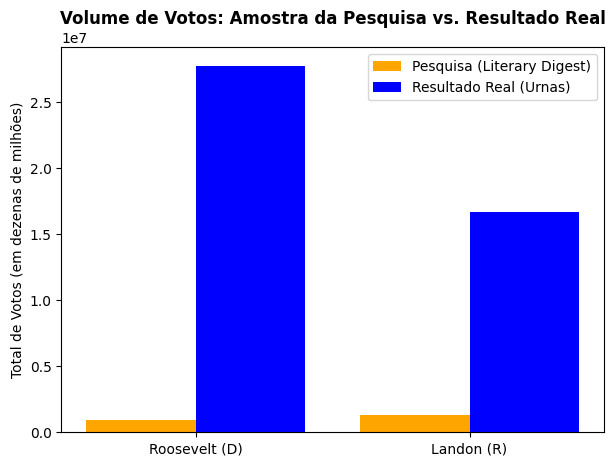

In [ ]:
candidatos = ['Roosevelt (D)', 'Landon (R)'] #defini os candidatos presentes
votos_pesquisa = [964819, 1283985]#peguei os votos declarados na pesquisa
votos_reais = [27752889, 16682763]#e os votos oficiais das urnas

plt.figure(figsize=(7, 5)) #defini o tamanho de novo

x = [0, 1] #fiz um grafico de barras, e descobri que fazendo desse modo, as barras ficam lado a lado
largura = 0.40 #Largura de cada barra

plt.bar([pos - largura/2 for pos in x], votos_pesquisa, width=largura, label='Pesquisa (Literary Digest)', color='orange') #Barras da Pesquisa(deslocadas um pouco para a esquerda)

plt.bar([pos + largura/2 for pos in x], votos_reais, width=largura, label='Resultado Real (Urnas)', color='blue') #barras do Resultado Real (deslocadas um pouco para a direita)

plt.ylabel('Total de Votos (em dezenas de milhões)') #aqui os eixos colocados
plt.title('Volume de Votos: Amostra da Pesquisa vs. Resultado Real', fontweight='bold') #o titulo
plt.xticks(x, candidatos) #coloca o nome dos candidatos no eixo X
plt.legend(loc='upper right') #legenda no canto superior direito

plt.show() #mostra

Nesse gráfico notamos a diferença enorme entre o volume de votos, as pesquisas possuíam um número muito abaixo do resultado real das urnas
concluimos com isso que mesmo a pesquisa tendo abrangido um numero grande de entrevistados, a dimensao da previsao não evitou um grande erro no resultado

## 9. Diagnóstico de Vieses

## 9.1 Viés de Amostragem

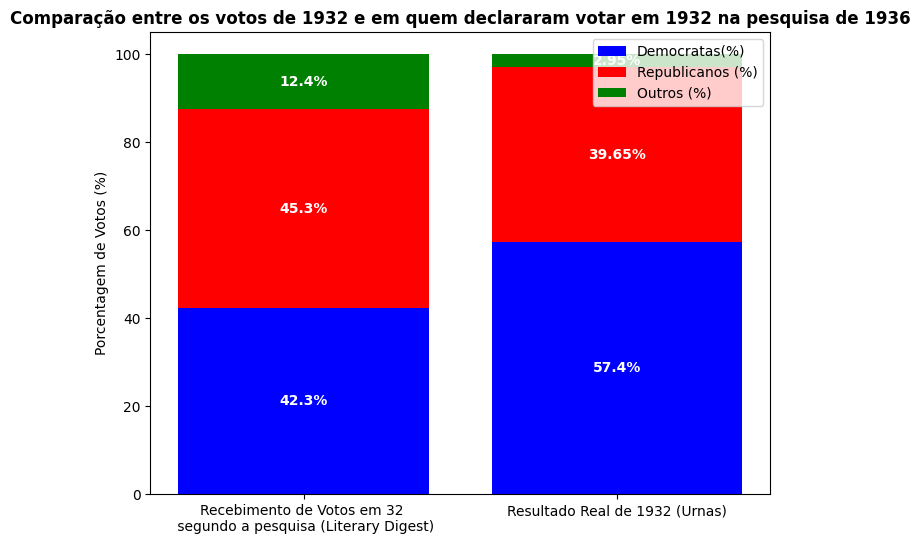

In [ ]:
categorias = [f'Recebimento de Votos em 32 \n segundo a pesquisa (Literary Digest)', 'Resultado Real de 1932 (Urnas)'] #as categorias
dem = [42.3, 57.4] #porcentagem declarada de votos de 32 na pesquisa de 36 e outra recebida dos democratas em 1932
rep = [45.3, 39.65] #mesma coisa aqui para os republicanos
outros= [12.4, 2.95] #mesma coisa aqui para nenhum dos dois partidos

plt.figure(figsize=(8, 6)) #defini o tamanho do grafico
bar1 = plt.bar(categorias, dem, label='Democratas(%)', color='blue')
bar2 = plt.bar(categorias, rep, bottom=dem, label='Republicanos (%)', color='red')
bar3 = plt.bar(categorias, outros, bottom=[dem[i]+rep[i] for i in range(len(categorias))], label='Outros (%)', color='green')

plt.ylabel('Porcentagem de Votos (%)') #criei o titulo ali do lado esquerdo presente no Y
plt.title('Comparação entre os votos de 1932 e em quem declararam votar em 1932 na pesquisa de 1936', fontweight='bold') #O titulo
plt.legend(loc='upper right') #e movi a legenda pro lado direito pois estava muito poluido do outro lado

#Texto que coloquei na primeira coluna (votos em 1932)
plt.text(1, 57.4 / 2, '57.4%', ha='center', va='center', color='white', fontweight='bold') #Democratas (barra de baixo), aqui eu coloquei a primeira coluna, e o alinhamento horizontal e vertical pra ficar certinho, a cor do texto e a fonte negrito
plt.text(1, 57.4 + (39.65 / 2), '39.65%', ha='center', va='center', color='white', fontweight='bold') #Republicanos
plt.text(1, 57.4 + ((39.65)+2.95/2), '2.95%', ha='center', va='center', color='white', fontweight='bold') #Outros

#texto na segunda coluna (pesquisa de 36 sobre em quem votou em 32)
plt.text(0, 42.3 / 2, '42.3%', ha='center', va='center', color='white', fontweight='bold')#Democratas (barra de baixo), mesma coisa aqui
plt.text(0, 42.3 + (45.3 / 2), '45.3%', ha='center', va='center', color='white', fontweight='bold') #Republicanos
plt.text(0, 42.3 + ((45.3)+12.4/2), '12.4%', ha='center', va='center', color='white', fontweight='bold') #Outros

plt.show() #Aqui eu mostrei

Após a análise do gráfico, observa-se uma diferença significativa entre a composição política dos eleitores em 1932 e a composição dos respondentes da pesquisa realizada pela Literary Digest em 1936, considerando como esses respondentes declararam ter votado no ano anterior. Nos resultados eleitorais de 1932, 57,4% dos votos foram destinados aos democratas, enquanto 39,65% foram destinados aos republicanos e aproximadamente 2% a outros candidatos. Entre os respondentes da pesquisa de 1936, entretanto, 42% declararam ter votado nos democratas e 45% nos republicanos, enquanto a participação dos demais grupos aumentou. Dessa forma, observa-se uma redução de aproximadamente 15 pontos percentuais na representação democrata e um aumento de aproximadamente 5 pontos percentuais na representação republicana entre as duas distribuições. Essa diferença indica que a composição política dos respondentes da pesquisa não correspondia à distribuição observada na eleição de 1932, fornecendo evidências de um possível problema de representatividade da amostra. Esse resultado ajuda a explicar por que uma pesquisa com um número tão elevado de respostas poderia ainda assim produzir uma previsão bastante distante do resultado eleitoral de 1936.

## 9.2 Viés de Não Resposta

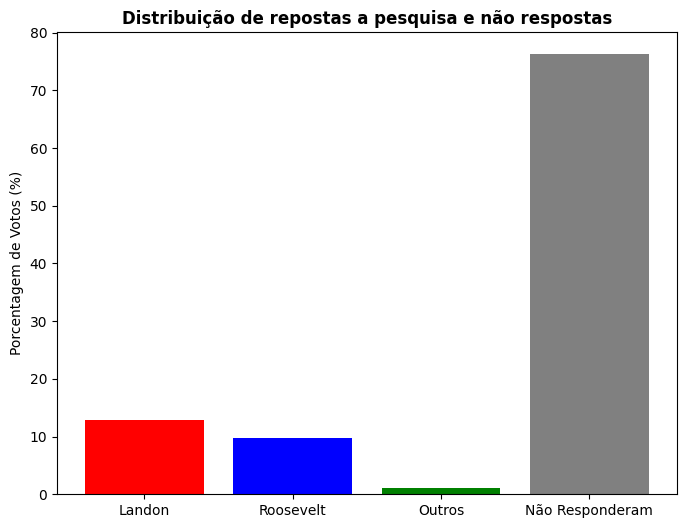

In [ ]:
categorias = ["Landon", "Roosevelt", "Outros", "Não Responderam"] #as categorias
valores = [12.94, 9.73, 1.10, 76.23]
plt.figure(figsize=(8, 6)) #defini o tamanho do grafico
plt.bar(categorias, valores, color=["red", "blue", "green", "gray"])

plt.ylabel('Porcentagem de Votos (%)') # Foi criado o titulo do lado esquerdo presente no Y
plt.title('Distribuição de repostas a pesquisa e não respostas', fontweight='bold') # O titulo

plt.show() # Aqui foi mostrado

Após a criação do gráfico, é possível perceber uma grande discrepância entre os valores declarados para cada candidato e a quantidade de pessoas que não responderam à pesquisa, que chega a aproximadamente 76%. Esse alto percentual de não respostas representa um possível problema de viés de não resposta, pois a pesquisa considera apenas as pessoas que efetivamente responderam ao questionário. Não é possível saber qual era a preferência política dos indivíduos que não responderam e, portanto, não podemos afirmar que a distribuição observada entre os respondentes representava a população geral. Por exemplo, caso os não respondentes apresentassem uma composição política diferente da observada entre os respondentes, o resultado estimado pela pesquisa poderia mudar significativamente.

## 10. Iniciando a Regressão

#### 10.1 definição de X e Y

In [ ]:
x = df_reg[["erro_Roosevelt_1932"]]
y = df_reg[["erro_Roosevelt"]]

Primeiro passamos as caracteristicas da pesquisa para X, ou seja a margem de erro de 1932(um valor mais aceitavel, pois naquele ano a pesquisa foi bem sucedida). e passamos a variavel alvo para y, a margem de erro de 1936.

#### 10.2 Separação de treino e teste

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
)

Fizemos aqui a separação dos dados de teste e treino, em 80% treino e 20% teste.

In [ ]:
print("X_train:", x_train.shape)
print("X_test :", x_test.shape)
print("\nDistribuição em y_train:")
print(y_train.value_counts())
print("\nDistribuição em y_test:")
print(y_test.value_counts())

X_train: (37, 1)
X_test : (10, 1)

Distribuição em y_train:
erro_Roosevelt
-60.635833        1
-45.333818        1
-37.076268        1
-36.095640        1
-35.148190        1
-34.755026        1
-34.479273        1
-31.847628        1
-29.719717        1
-29.351903        1
-29.255415        1
-27.069250        1
-24.885467        1
-23.934360        1
-22.702773        1
-21.320545        1
-19.599435        1
-18.768378        1
-17.456473        1
-17.378501        1
-17.188848        1
-15.391603        1
-14.047874        1
-14.037386        1
-13.720464        1
-9.986667         1
-9.104415         1
-0.857542         1
 0.886592         1
 5.714756         1
 6.470969         1
 12.715387        1
 13.041509        1
 13.469163        1
 22.057118        1
 26.458477        1
 30.846221        1
Name: count, dtype: int64

Distribuição em y_test:
erro_Roosevelt
-74.809444        1
-37.316876        1
-34.734172        1
-31.557180        1
-29.947773        1
-20.566515        1

Aqui conferimos se os valores realmente foram divididos da forma solicitada e se não houve nenhum erro.

#### 10.3 Criação do modelo e treino dele

In [ ]:
modelo = LinearRegression()
modelo.fit(x_train, y_train)

LinearRegression()

passamos para a maquina que o modelo desejado é Regressão Linear(LinearRegression()) e depois disso treinamos o modelo com .fit e passando os dados de treino x e y

#### 10.4 Coeficiente e Intercepto

In [ ]:
print("Coeficiente:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Coeficiente: [0.30964258]
Intercepto: [-16.01188926]


nesses dois prints, primeiro calculamos o coefieciente com nosso modelo de regressão. Tentamos descobrir quantos pontos de erro se aumenta na margem de 36 se aumentar 1 ponto em 32. nesse caso foi 0.3. Já o intercepto é o valor previsto para margem de erro de 36 se a margem de erro de 32 for 0. Nesse caso é -16.

#### 10.5 Teste do modelo

In [ ]:
df_reg["erro_1936_previsto"] = modelo.predict(x)

Após fazer esses calculos, fazemos o predict com o modelo, salvando eles no dataframe como erro previsto de 1936.

In [ ]:
df_reg[["State - 1936","erro_Roosevelt_1932","erro_Roosevelt","erro_1936_previsto"]].head(10)

,State - 1936,erro_Roosevelt_1932,erro_Roosevelt,erro_1936_previsto
0,Arizona,15.48545,6.470969,-11.216934
1,Arkansas,-20.353373,-37.076268,-22.314160
2,California,22.991351,5.714756,-8.892788
3,Colorado,9.71273,-15.391603,-13.004415
4,Connecticut,7.083126,-17.565321,-13.818652
5,Delaware,-9.164598,-23.934360,-18.849639
6,Florida,-23.036998,-35.148190,-23.145125
7,Georgia,-35.354168,-29.255415,-26.959045
8,Idaho,13.073317,13.469163,-11.963834
9,Illinois,31.618277,-17.456473,-6.221525


Aqui printamos a tabela com a nova coluna erro previsto.

In [ ]:
df_reg["Roosevelt_corrigido_modelo"] = (df_reg["Roosevelt_pesquisa"] -df_reg["erro_1936_previsto"])

Agora vamos corrigir de acordo com o modelo, subtraindo do valor obtido na pesquisa a margem de erro definida pelo modelo.

In [ ]:
df_reg[["State - 1936","Roosevelt_pesquisa","erro_1936_previsto","Roosevelt_corrigido_modelo","%_x"
]].head(10)

,State - 1936,Roosevelt_pesquisa,erro_1936_previsto,Roosevelt_corrigido_modelo,%_x
0,Arizona,76.320969,-11.216934,87.537903,69.85
1,Arkansas,44.723732,-22.314160,67.037892,81.80
2,California,72.664756,-8.892788,81.557544,66.95
3,Colorado,44.978397,-13.004415,57.982812,60.37
4,Connecticut,37.754679,-13.818652,51.573331,55.32
5,Delaware,30.685640,-18.849639,49.535279,54.62
6,Florida,40.951810,-23.145125,64.096934,76.10
7,Georgia,57.844585,-26.959045,84.803629,87.10
8,Idaho,76.429163,-11.963834,88.392997,62.96
9,Illinois,40.243527,-6.221525,46.465051,57.70


Agora, é mostrado na tabela novamente o valor da pesquisa, e o que deveria ser de acordo com o modelo e na ultima coluna o resultado oficial, já é possivel ver que em muitos estado o valor se aproximou do que foi oficialmente.

In [ ]:
df_reg["erro_modelo_abs"] = (df_reg["Roosevelt_corrigido_modelo"] - df_reg["%_x"]).abs()

fazendo o erro absoluto do modelo

In [ ]:
df_reg["erro_original_abs"] = ( df_reg["Roosevelt_pesquisa"] - df_reg["%_x"]).abs()

fazendo o erro absoluto do modelo

In [ ]:
mae_original = df_reg["erro_original_abs"].mean()
mae_modelo = df_reg["erro_modelo_abs"].mean()

print("Erro médio original:",
      mae_original)

print("Erro médio após regressão:",
      mae_modelo)

Erro médio original: 23.28304150341117
Erro médio após regressão: 14.907044551110376


fazendo as medias dos erros, original e do modelo, quanto mais proximo de 0 melhor, é possivel ver que o modelo reduziu a margem de erro em quase 10 pontos.

In [ ]:
reducao_erro = ((mae_original - mae_modelo) / mae_original) * 100

print(f"Redução do erro médio entre original e após regressão: {reducao_erro:.2f}%")

Redução do erro médio entre original e após regressão: 35.97%


In [ ]:
r2 = r2_score(
    df_reg["erro_Roosevelt"],
    df_reg["erro_1936_previsto"]
)

print("R²:", r2)

R²: 0.13111764650480007


O modelo apresentou R² = 0,1311, indicando que aproximadamente 13,1% da variação observada no erro da pesquisa de 1936 é explicada pelo erro observado em 1932. Esse valor indica que a variável utilizada como âncora possui capacidade explicativa limitada, sugerindo que outros fatores também contribuíram para os erros observados em 1936.

#### 10.5 Criação de visualização do modelo

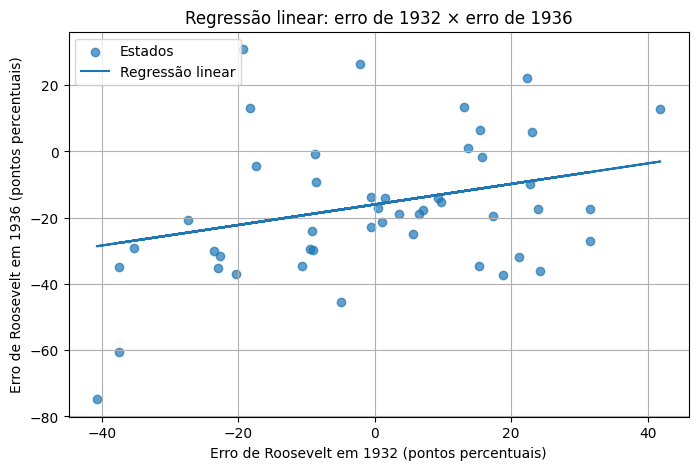

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_reg["erro_Roosevelt_1932"],
    df_reg["erro_Roosevelt"],
    alpha=0.7,
    label="Estados"
)

plt.plot(
    df_reg["erro_Roosevelt_1932"],
    df_reg["erro_1936_previsto"],
    label="Regressão linear"
)

plt.xlabel("Erro de Roosevelt em 1932 (pontos percentuais)")
plt.ylabel("Erro de Roosevelt em 1936 (pontos percentuais)")
plt.title("Regressão linear: erro de 1932 × erro de 1936")
plt.legend()
plt.grid(True)

plt.show()

Criação de um grafico de dispersão, onde cada ponto é um estado. no eixo x temos os pontos percentuais de 32 e no y de 36, já a linha é os valores previstos pela regressão

# 11. Métricas Finais

In [ ]:
print("MÉTRICAS FINAIS")
print("-----------------------------")
print(f"MAE original: {mae_original:.2f} pontos percentuais")
print(f"MAE após regressão: {mae_modelo:.2f} pontos percentuais")
print(f"Redução do MAE: {reducao_erro:.2f} pontos percentuais")
print(f"R² da regressão: {r2:.4f}")

MÉTRICAS FINAIS
-----------------------------
MAE original: 23.28 pontos percentuais
MAE após regressão: 14.91 pontos percentuais
Redução do MAE: 35.97 pontos percentuais
R² da regressão: 0.1311


As métricas indicam que a regressão linear reduziu o erro médio das estimativas de Roosevelt, passando de 23,28 para 14,91 pontos percentuais. Isso representa uma redução de 35,97% no MAE, indicando uma diminuição relevante do erro médio após a aplicação do modelo. O R² de 0,1311 indica que o erro observado em 1932 explica cerca de 13,1% da variação do erro observado em 1936.

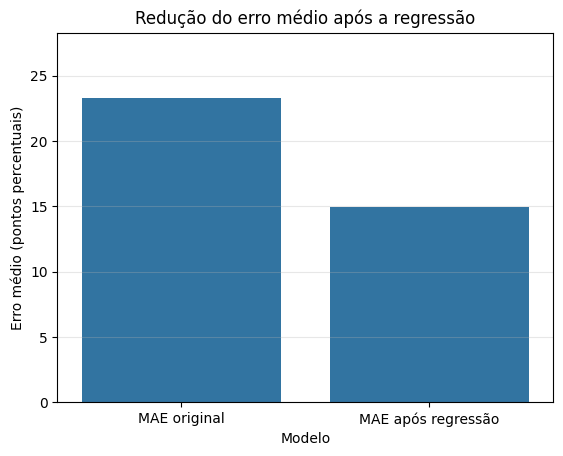

In [ ]:
metricas = ["MAE original", "MAE após regressão"]
valores = [mae_original, mae_modelo]

sns.barplot(x=metricas, y=valores)

plt.title("Redução do erro médio após a regressão")
plt.ylabel("Erro médio (pontos percentuais)")
plt.xlabel("Modelo")

plt.ylim(0, max(valores) + 5)
plt.grid(axis="y", alpha=0.3)

plt.show()

O gráfico apresenta uma comparação entre o MAE (Erro Médio Absoluto) das estimativas originais da pesquisa e das estimativas após a aplicação da regressão linear. Essa visualização permite observar de forma direta a redução do erro obtida pelo modelo, que passou de 23,28 para 14,91 pontos percentuais, representando uma redução de aproximadamente 35,97% no MAE.

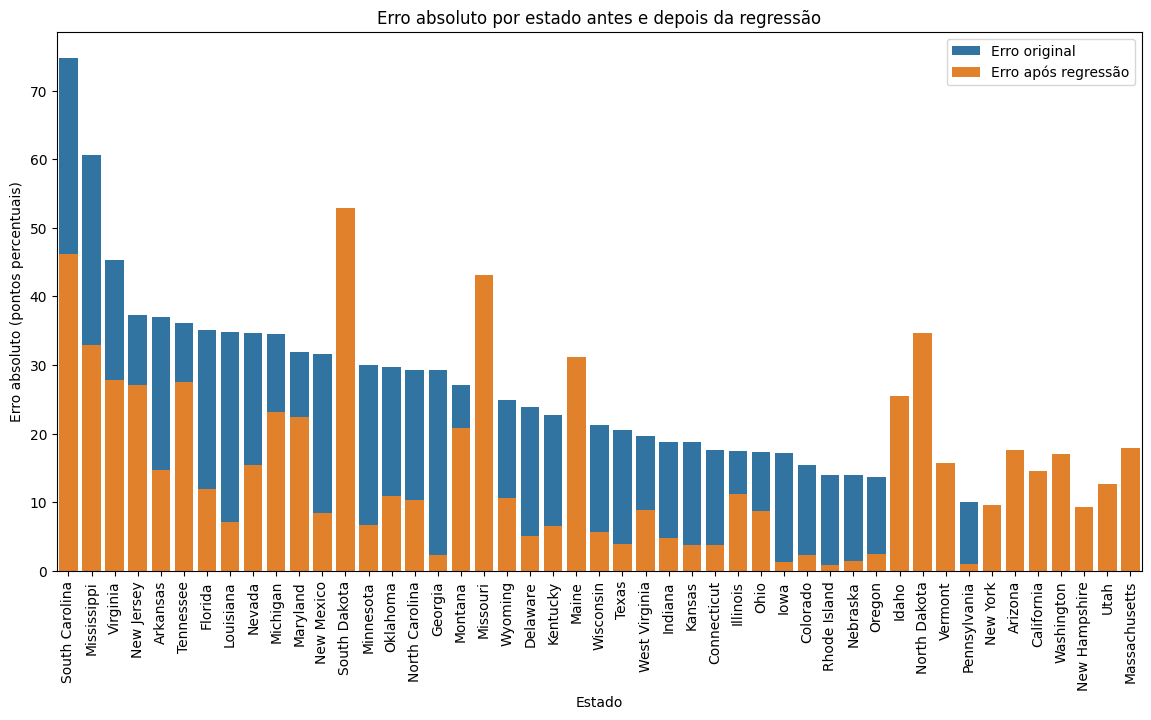

In [ ]:
# Comparação do erro por estado antes e depois da regressão

df_grafico = df_reg[[
    "State - 1936",
    "erro_Roosevelt",
    "erro_1936_previsto"
]].copy()

df_grafico["erro_original_abs"] = df_grafico["erro_Roosevelt"].abs()
df_grafico["erro_corrigido_abs"] = (
    df_grafico["erro_Roosevelt"] - df_grafico["erro_1936_previsto"]
).abs()

df_grafico = df_grafico.sort_values(
    "erro_original_abs",
    ascending=False
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_grafico,
    x="State - 1936",
    y="erro_original_abs",
    label="Erro original"
)

sns.barplot(
    data=df_grafico,
    x="State - 1936",
    y="erro_corrigido_abs",
    label="Erro após regressão"
)

plt.title("Erro absoluto por estado antes e depois da regressão")
plt.xlabel("Estado")
plt.ylabel("Erro absoluto (pontos percentuais)")
plt.xticks(rotation=90)
plt.legend()

plt.show()

O gráfico apresenta o erro absoluto das estimativas de Roosevelt em cada estado, comparando os valores originais da pesquisa com os valores após a correção baseada na regressão linear. Essa visualização permite identificar, de forma mais detalhada, em quais estados a aplicação do modelo contribuiu para reduzir o erro e onde a diferença entre a estimativa e o resultado real permaneceu elevada.

# 12. Estimativa Final

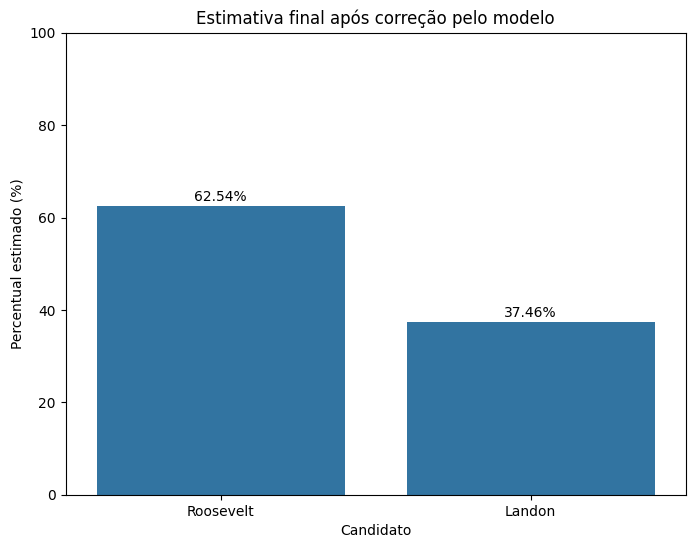

In [ ]:
# Comparação da estimativa final entre Roosevelt e Landon

roosevelt_final = df_reg["Roosevelt_corrigido_modelo"].mean()

landon_final = 100 - roosevelt_final

resultado_final = pd.DataFrame({
    "Candidato": ["Roosevelt", "Landon"],
    "Estimativa (%)": [roosevelt_final, landon_final]
})

plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=resultado_final,
    x="Candidato",
    y="Estimativa (%)"
)

for i, valor in enumerate(resultado_final["Estimativa (%)"]):
    ax.text(i, valor + 1, f"{valor:.2f}%", ha="center")

plt.title("Estimativa final após correção pelo modelo")
plt.xlabel("Candidato")
plt.ylabel("Percentual estimado (%)")
plt.ylim(0, 100)

plt.show()

O gráfico apresenta a estimativa final das intenções de voto para Roosevelt e Landon após a aplicação da correção baseada na regressão linear. A comparação permite visualizar como as métricas e o ajuste do modelo modificaram a estimativa inicial da pesquisa. O candidato com maior percentual na estimativa final representa o Roosevelt como vencedor, condizendo com o resultado da época.

# 13. Conclusão

O trabalho teve como objetivo analisar os resultados das pesquisas eleitorais da Literary Digest e verificar como técnicas de análise de dados e modelagem preditiva poderiam ser utilizadas para compreender e corrigir os erros das estimativas. Inicialmente, foram organizadas as bases referentes às eleições de 1932 e 1936, identificando as variáveis relacionadas às respostas da pesquisa, aos resultados eleitorais reais e às informações por estado. Em seguida, foram removidas as linhas de totalização e realizadas as transformações necessárias para calcular os percentuais de intenção de voto e comparar as estimativas da pesquisa com os resultados reais.

Na etapa seguinte, foi calculado o erro da pesquisa para Roosevelt em 1932, utilizando a diferença entre o percentual estimado pela Literary Digest e o percentual obtido na eleição. Esse erro foi utilizado como referência para construir uma Regressão Linear simples, com o objetivo de estimar o erro da pesquisa de 1936. A partir do erro previsto pelo modelo, foi realizada uma correção nas estimativas de 1936. Para avaliar os resultados, foram utilizados o MAE (Erro Médio Absoluto) e o R². O MAE passou de 23,28 para 14,91 pontos percentuais, representando uma redução de aproximadamente 35,97% no erro médio. O modelo apresentou R² de 0,1311, indicando que o erro observado em 1932 explica aproximadamente 13,1% da variação do erro observado em 1936 dentro do modelo analisado. Por fim, foram produzidas visualizações para comparar os erros antes e depois da regressão e analisar seu comportamento por estado.

O que pode ser concluído

A análise mostra que o modelo conseguiu reduzir consideravelmente o erro médio das estimativas de Roosevelt, embora sua capacidade explicativa tenha sido limitada. Isso indica que o erro de 1932 possui alguma relação com o erro de 1936, mas não é suficiente, sozinho, para explicar grande parte de sua variação. Dessa forma, a regressão demonstra como técnicas simples de Machine Learning podem ser utilizadas para identificar padrões históricos e ajustar estimativas, mas também evidencia a importância de considerar outras variáveis para obter um modelo mais completo. O trabalho demonstra, na prática, todo o processo de preparação dos dados, análise, cálculo de erros, modelagem, avaliação por métricas e interpretação dos resultados.